In [1]:
# from xopr_gline import xopr_utils
import numpy as np
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import scipy.constants
from scipy import signal
import pandas as pd
import geopandas as gpd
import xopr.opr_access
import xopr.geometry
import dask
from dask.distributed import LocalCluster
import cartopy.crs as ccrs
import geoviews.feature as gf
import time
import requests
from scipy.optimize import curve_fit

from xopr_gline.xopr_utils import extract_layer_peak_power, surface_bed_reflection_power, get_basal_layer_wgs84
from xopr_gline.empirical import erf_topography_model, get_derivatives

In [2]:
opr = xopr.opr_access.OPRConnection(cache_dir="/tmp")

Use the `get_greenland_regions` methods to select the area of interest 

In [3]:
# region = xopr.geometry.get_greenland_regions(name='PETERMANN_GLETSCHER')

In [40]:
# Select a segment
selected_collection = "2010_Greenland_DC8"
selected_segment = "20100420_03"
print(f"Selected segment: {selected_segment}")

# Query frames
stac_items = opr.query_frames(
    collections=[selected_collection], segment_paths=[selected_segment]
)
print(f"Found {len(stac_items)} frames")
stac_items = stac_items.iloc[7:11]
stac_items

Selected segment: 20100420_03
Found 22 frames


,collection,geometry,properties,assets,bbox,id,links,stac_extensions,stac_version,type
stac_item_id,,,,,,,,,,
Data_20100420_03_008,2010_Greenland_DC8,"LINESTRING (-62.44668 81.33035, -62.40026 81.3...",{'datetime': '2010-04-20T18:11:15.995419+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-62.446682454400914, 80.9054754941615, -61.22...",Data_20100420_03_008,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100420_03_009,2010_Greenland_DC8,"LINESTRING (-61.27258 80.92154, -60.66166 80.7...",{'datetime': '2010-04-20T18:17:04.516143+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-61.27258317305416, 80.54199019372452, -59.70...",Data_20100420_03_009,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100420_03_010,2010_Greenland_DC8,"LINESTRING (-59.77646 80.55455, -58.3045 80.29...",{'datetime': '2010-04-20T18:22:37.777530+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-59.77646464580275, 80.22844865415611, -57.79...",Data_20100420_03_010,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100420_03_011,2010_Greenland_DC8,"LINESTRING (-57.87752 80.23955, -57.71175 80.2...",{'datetime': '2010-04-20T18:27:04.988342+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-57.877522863471064, 80.12808632986624, -56.4...",Data_20100420_03_011,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature


In [41]:
# get a specific line from Petermann
# stac_items = opr.query_frames(geometry=region, date_range="2006/2015")

# if we know the specific segment we can query like this 
# # stac_items = opr.query_frames(segment_paths='20100420_03')

In [42]:
# petermann_line_string = gpd.GeoSeries(petermann_line_stac['geometry'], crs=4326)
# petermann_line_string.to_file('/home/laserglaciers/petermann_grounding_zones/petermann_Data_20100420_03_009.gpkg',
#                               driver='GPKG')

In [43]:
# Load the radar data
frames = opr.load_frames(stac_items)
print(f"Loaded {len(frames)} frames")

Loaded 4 frames


In [44]:
# Merge frames into a single flight line
flight_line = xopr.merge_frames(frames)
flight_line

/home/m484s199/xopr-gline/.venv/lib/python3.11/site-packages/xopr/opr_tools.py:57: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  merged_segment = xr.concat(segment_frames, dim='slow_time', combine_attrs=merge_dicts_no_conflicts).sortby('slow_time')


<xarray.Dataset> Size: 157MB
Dimensions:    (slow_time: 12715, twtt: 769)
Coordinates:
  * slow_time  (slow_time) datetime64[ns] 102kB 2010-04-20T18:08:13.892762184...
  * twtt       (twtt) float64 6kB -1.999e-06 -1.894e-06 ... 7.878e-05 7.889e-05
Data variables:
    Time       (slow_time, twtt) float64 78MB -1.999e-06 ... 7.889e-05
    GPS_time   (slow_time) float64 102kB 1.272e+09 1.272e+09 ... 1.272e+09
    Latitude   (slow_time) float64 102kB 81.33 81.33 81.33 ... 80.13 80.13 80.13
    Longitude  (slow_time) float64 102kB -62.45 -62.45 -62.45 ... -56.41 -56.41
    Elevation  (slow_time) float64 102kB 493.3 493.3 493.3 ... 1.61e+03 1.61e+03
    Surface    (slow_time) float64 102kB 3.183e-06 3.183e-06 ... nan nan
    Data       (twtt, slow_time) float64 78MB 2.681e-31 2.835e-31 ... 5.343e-36
Attributes: (12/21)
    param_combine_wf_chan:  {'sw_version': {'ver': '1.0', 'date_time': '20110...
    institution:            Open Polar Radar (OPR)
    comment:                Polar radar echogram data with CF-compliant metadata
    Conventions:            CF-1.8
    array_param:            {'sv': array([1, 1, 1, 1, 1], dtype=uint8), 'supp...
    mimetype:               application/x-matlab-data
    ...                     ...
    segment:                3
    history:                Converted to CF-compliant format on 2026-02-13T20...
    param_radar:            {'sample_size': 2, 'wfs': [{'Tpd': 1e-06, 't0': -...
    references:             https://gitlab.com/englacial/xopr
    source_url:             {'https://data.cresis.ku.edu/data/rds/2010_Greenl...
    granule:                {'20100420_03_008', '20100420_03_009', '20100420_...

In [45]:
# Load layers for the merged flight line
layers = opr.get_layers(flight_line)
print(f"Available layers: {list(layers.keys())}")

Available layers: ['standard:surface', 'standard:bottom']


In [46]:
for layer_idx in layers:
    layers[layer_idx] = xopr.radar_util.add_along_track(layers[layer_idx])
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='wgs84')
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='range')

flight_line = xopr.radar_util.add_along_track(flight_line)
flight_line = xopr.radar_util.interpolate_to_vertical_grid(flight_line, vertical_coordinate='wgs84')


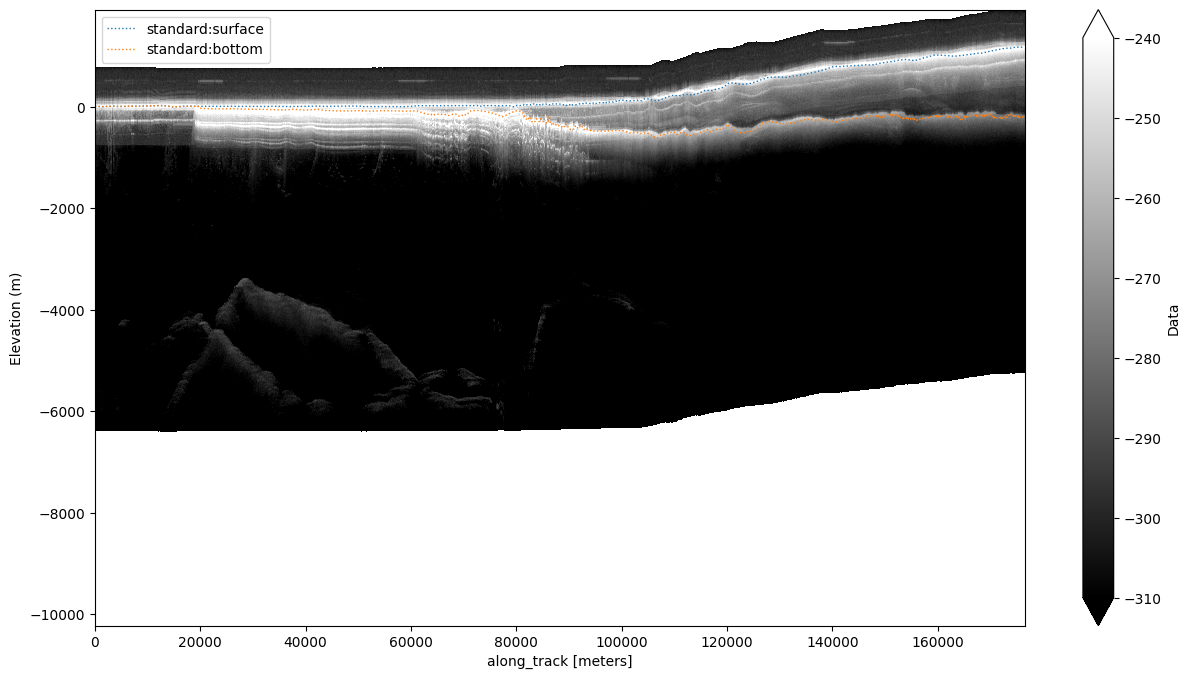

In [47]:
# visualize radargram

clb_min_pct, clb_max_pct  = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=-310, vmax=-240) #-310 -240

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
# ax1.set_xlim(0.3e6, 0.5e6)

Add in grounding zone data from Ciracì et al 2023 (https://pnas.org/doi/10.1073/pnas.2220924120)

In [48]:
gz_path = '../data/petermann_grounding_zones.geojson'
gz_gdf = gpd.read_file(gz_path)
gz_gdf.crs

<Projected CRS: EPSG:3413>
Name: WGS 84 / NSIDC Sea Ice Polar Stereographic North
Axis Info [cartesian]:
- X[south]: Easting (metre)
- Y[south]: Northing (metre)
Area of Use:
- name: Northern hemisphere - north of 60°N onshore and offshore, including Arctic.
- bounds: (-180.0, 60.0, 180.0, 90.0)
Coordinate Operation:
- name: US NSIDC Sea Ice polar stereographic north
- method: Polar Stereographic (variant B)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [49]:
layers['standard:surface']

<xarray.Dataset> Size: 795kB
Dimensions:       (slow_time: 12046)
Coordinates:
  * slow_time     (slow_time) datetime64[ns] 96kB 2010-04-20T18:08:13.9047036...
    along_track   (slow_time) float64 96kB 0.0 14.63 ... 1.764e+05 1.764e+05
Data variables:
    file_type     <U5 20B 'layer'
    file_version  <U1 4B '1'
    elev          (slow_time) float64 96kB 489.8 489.8 ... 1.605e+03 1.605e+03
    id            float64 8B 1.0
    Latitude      (slow_time) float64 96kB 81.35 81.35 81.35 ... 80.14 80.14
    Longitude     (slow_time) float64 96kB -62.48 -62.48 ... -56.52 -56.52
    quality       (slow_time) uint8 12kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    twtt          (slow_time) float64 96kB 3.178e-06 3.179e-06 ... 2.844e-06
    type          (slow_time) uint8 12kB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2 2
    wgs84         (slow_time) float64 96kB 13.43 13.38 ... 1.179e+03 1.179e+03
    range         (slow_time) float64 96kB 476.4 476.5 476.5 ... 425.8 426.3

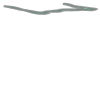

In [50]:
gz_gdf_4326 = gz_gdf.to_crs(4326)
gz_gdf_4326[gz_gdf_4326['layer'] == '2011_2015']
gz_2011 = gz_gdf_4326[gz_gdf_4326['layer'] == '2011_2015']
gz_2011['geometry'][0]

In [51]:


def interpolate_points_along_line(geoSeries):
    distances = np.arange(0, geoSeries[0].length, 2)
    line = geoSeries.geometry
    # Filter out distances greater than the line length if necessary
    # valid_distances = distances[distances <= line.length]
    points = [line.interpolate(distance) for distance in distances]
    
    return points

pts = interpolate_points_along_line(segment_line)
len(pts)

NameError: name 'segment_line' is not defined

In [52]:
segment_line[0].length
# distances

NameError: name 'segment_line' is not defined

In [53]:
flight_line = flight_line.assign_coords({"Latitude": flight_line["Latitude"]})
flight_line = flight_line.assign_coords({"Longitude": flight_line["Longitude"]})
flight_line['along_track'].data[-1]

np.float64(176511.3735053325)

In [54]:
flight_line

<xarray.Dataset> Size: 141MB
Dimensions:      (slow_time: 12715, wgs84: 1214, twtt: 769)
Coordinates:
  * slow_time    (slow_time) datetime64[ns] 102kB 2010-04-20T18:08:13.8927621...
  * wgs84        (wgs84) float64 10kB -1.022e+04 -1.021e+04 ... 1.915e+03
  * twtt         (twtt) float64 6kB -1.999e-06 -1.894e-06 ... 7.889e-05
    along_track  (slow_time) float64 102kB 0.0 14.23 ... 1.765e+05 1.765e+05
    Latitude     (slow_time) float64 102kB 81.33 81.33 81.33 ... 80.13 80.13
    Longitude    (slow_time) float64 102kB -62.45 -62.45 ... -56.41 -56.41
Data variables:
    Data         (slow_time, wgs84) float32 62MB -1.0 -1.0 ... 3.741e-31 -2.0
    Time         (slow_time, twtt) float64 78MB -1.999e-06 ... 7.889e-05
    GPS_time     (slow_time) float64 102kB 1.272e+09 1.272e+09 ... 1.272e+09
    Elevation    (slow_time) float64 102kB 493.3 493.3 ... 1.61e+03 1.61e+03
    Surface      (slow_time) float64 102kB 3.183e-06 3.183e-06 ... nan nan
Attributes: (12/21)
    param_combine_wf_chan:  {'sw_version': {'ver': '1.0', 'date_time': '20110...
    institution:            Open Polar Radar (OPR)
    comment:                Polar radar echogram data with CF-compliant metadata
    Conventions:            CF-1.8
    array_param:            {'sv': array([1, 1, 1, 1, 1], dtype=uint8), 'supp...
    mimetype:               application/x-matlab-data
    ...                     ...
    segment:                3
    history:                Converted to CF-compliant format on 2026-02-13T20...
    param_radar:            {'sample_size': 2, 'wfs': [{'Tpd': 1e-06, 't0': -...
    references:             https://gitlab.com/englacial/xopr
    source_url:             {'https://data.cresis.ku.edu/data/rds/2010_Greenl...
    granule:                {'20100420_03_008', '20100420_03_009', '20100420_...

In [55]:
flight_line['Longitude'].to_index().is_monotonic_increasing

True

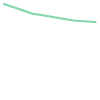

In [56]:
from shapely.geometry import Point, LineString

flight_line_proj = xopr.geometry.project_dataset(flight_line, "EPSG:3413")
xy_points = gpd.points_from_xy(flight_line_proj['x'], flight_line_proj['y'])
lon_lat_points = gpd.points_from_xy(flight_line['Longitude'], flight_line['Latitude'])

flight_line_3413 = LineString(xy_points)
flight_line_4326 = LineString(lon_lat_points)
flight_line_4326

<Axes: >

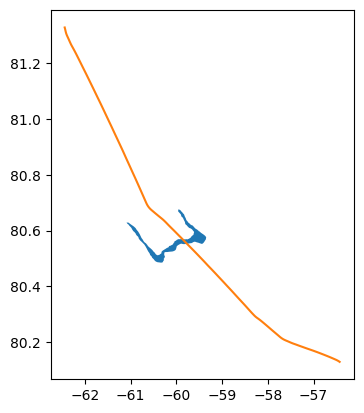

In [57]:
fig, ax = plt.subplots()
segment_geom_gpd = gpd.GeoSeries(flight_line_4326)
segment_geom_gpd.plot(ax=ax, color='tab:orange')
gz_2011.plot(ax=ax)
# ax.get_xlim()

In [58]:

segment_geom = segment_geom_gpd[0].intersection(gz_2011['geometry'][0])
# segment_geom
segment_geom_coords = list(segment_geom.coords)
# segment_geom_coords
segment_geom_coords = np.array(segment_geom_coords)
lons = segment_geom_coords[:,0]
lats = segment_geom_coords[:,1]
lons[0]

np.float64(-59.862946967824634)

In [59]:
slow_time_lat1 = flight_line.swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[0], method='nearest')['slow_time']
slow_time_lat2 = flight_line.swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[-1], method='nearest')['slow_time']
print(f'slow_time lat 1: {slow_time_lat1.data}\nslow_time lat 2: {slow_time_lat2.data}')


slow_time lat 1: 2010-04-20T18:19:28.694723129
slow_time lat 2: 2010-04-20T18:19:45.461466789


In [60]:
slow_time_lon1 = flight_line.swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[0], method='nearest')['slow_time']
slow_time_lon2 = flight_line.swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[-1], method='nearest')['slow_time']
print(f'slow_time lon 1: {slow_time_lon1.data}\nslow_time lon 2: {slow_time_lon2.data}')

slow_time lon 1: 2010-04-20T18:19:28.694723129
slow_time lon 2: 2010-04-20T18:19:45.461466789


In [61]:
along_track_lon1 = flight_line['along_track'].sel(slow_time=slow_time_lon1)
along_track_lon2 = flight_line['along_track'].sel(slow_time=slow_time_lon1)

along_track_lat1 = flight_line['along_track'].sel(slow_time=slow_time_lat1)
along_track_lat2 = flight_line['along_track'].sel(slow_time=slow_time_lat2)

print(f'lon 1 {along_track_lon1.data} ...... lat 1 {along_track_lat1.data}')

lon 1 95379.4250260646 ...... lat 1 95379.4250260646


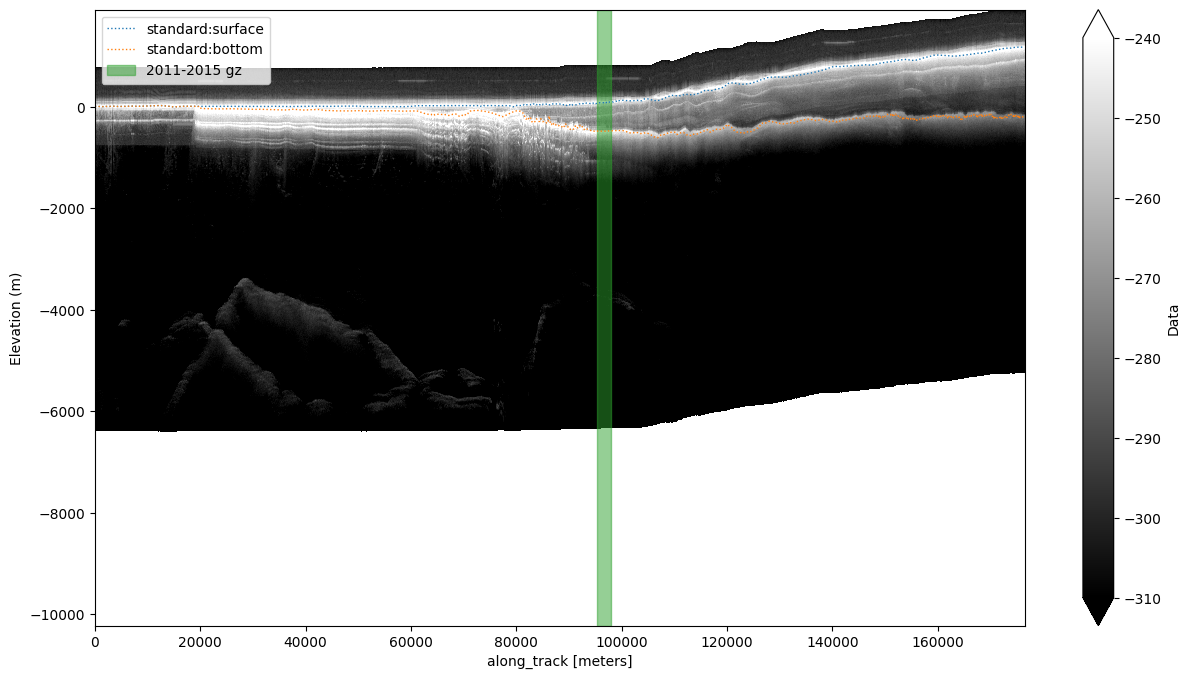

In [62]:
# visualize radargram

clb_min_pct, clb_max_pct = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=-310, vmax=-240)

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)


ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()

In [63]:
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Latitude": layers['standard:surface']["Latitude"]})
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Longitude": layers['standard:surface']["Longitude"]})

layers['standard:surface']['along_track'].data[-1]

np.float64(176398.45617763684)

In [64]:
# layers['standard:surface'] = layers['standard:surface'].assign_coords({"Latitude": layers['standard:surface']["Latitude"]})
slow_time_lat1 = layers['standard:surface'].swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[0], method='nearest')['slow_time']
slow_time_lat2 = layers['standard:surface'].swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[1], method='nearest')['slow_time']
print(f'slow_time lat 1: {slow_time_lat1.data}\nslow_time lat 2: {slow_time_lat2.data}')

slow_time lat 1: 2010-04-20T18:19:43.817803144
slow_time lat 2: 2010-04-20T18:19:43.817803144


In [65]:
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Longitude": layers['standard:surface']["Longitude"]})
slow_time_lon1 = layers['standard:surface'].swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[0], method='nearest')['slow_time']
slow_time_lon2 = layers['standard:surface'].swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[1], method='nearest')['slow_time']
print(f'slow_time lon 1: {slow_time_lon1.data}\nslow_time lon 2: {slow_time_lon2.data}')

slow_time lon 1: 2010-04-20T18:19:43.817803144
slow_time lon 2: 2010-04-20T18:19:43.817803144


In [66]:
layers['standard:surface'].indexes

Indexes:
    slow_time  DatetimeIndex(['2010-04-20 18:08:13.904703617',
               '2010-04-20 18:08:14.008635998',
               '2010-04-20 18:08:14.112572193',
               '2010-04-20 18:08:14.216497183',
               '2010-04-20 18:08:14.320423365',
               '2010-04-20 18:08:14.424345255',
               '2010-04-20 18:08:14.528260230',
               '2010-04-20 18:08:14.632165194',
               '2010-04-20 18:08:14.736072063',
               '2010-04-20 18:08:14.839981794',
               ...
               '2010-04-20 18:28:46.510581970',
               '2010-04-20 18:28:46.609615564',
               '2010-04-20 18:28:46.708642960',
               '2010-04-20 18:28:46.807666779',
               '2010-04-20 18:28:46.906685829',
               '2010-04-20 18:28:47.005703688',
               '2010-04-20 18:28:47.104717731',
               '2010-04-20 18:28:47.203729153',
               '2010-04-20 18:28:47.302737474',
               '2010-04-20 18:28:47.401740551

In [67]:
len(layers['standard:surface']["Longitude"])

12046

In [73]:
stac_items['assets']

stac_item_id
Data_20100420_03_008    {'CSARP_standard': {'href': 'https://data.cres...
Data_20100420_03_009    {'CSARP_standard': {'href': 'https://data.cres...
Data_20100420_03_010    {'CSARP_standard': {'href': 'https://data.cres...
Data_20100420_03_011    {'CSARP_standard': {'href': 'https://data.cres...
Name: assets, dtype: object

In [75]:
import dask
from dask.distributed import LocalCluster

client = LocalCluster().get_client()

In [76]:
stac_list = [row for _, row in stac_items.iterrows()]
futures = client.map(surface_bed_reflection_power, stac_list, opr=opr)

# Process results as they complete, capturing exceptions
results = []
for future in dask.distributed.as_completed(futures):
    try:
        result = future.result()
        results.append(result)
    except Exception as e:
        print(traceback.format_exc())

/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:82: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([reflectivity_dataset, flight_line_metadata])
/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:82: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([reflectivity_datase

In [80]:
reflectivity_merged = xr.merge(results, compat='override')
reflectivity_merged

/tmp/ipykernel_16710/1990311026.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_merged = xr.merge(results, compat='override')


<xarray.Dataset> Size: 18kB
Dimensions:           (slow_time: 248)
Coordinates:
  * slow_time         (slow_time) datetime64[ns] 2kB 2010-04-20T18:08:10 ... ...
Data variables:
    surface_twtt      (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    bed_twtt          (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    surface_power_dB  (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    bed_power_dB      (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    GPS_time          (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    Latitude          (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    Longitude         (slow_time) float64 2kB nan nan nan nan ... nan nan nan
    Elevation         (slow_time) float64 2kB nan nan nan nan ... nan nan nan
Attributes:
    segment:  3

In [91]:
results[1]['bed_power_dB']

<xarray.DataArray 'bed_power_dB' (slow_time: 72)> Size: 576B
array([          nan,           nan,           nan,           nan,
                 nan,           nan, -241.56805592, -244.21547154,
       -243.99631188, -244.70636818, -247.12809528, -250.41164747,
       -255.80477576, -249.32533742, -253.63488489, -246.77991974,
       -249.26423462, -252.16582929, -248.2929991 , -248.5821588 ,
       -260.58340098, -255.77037185, -254.86570348, -250.28701145,
       -251.12249741, -253.27329065, -255.58342002, -256.76622016,
       -256.10511678, -255.96447123, -257.311404  , -256.91798856,
       -261.67228774, -263.0667815 , -263.22339621, -266.63367023,
       -268.23876053, -268.63142388, -263.37273064, -261.83689589,
       -261.64857925, -259.76677622, -260.92501198, -259.90219743,
       -262.6288934 , -261.48510305, -260.20327858, -261.62310671,
       -259.93388705, -255.40531036, -255.14331303, -255.06464825,
       -256.13059047, -259.16341062, -258.97077774, -257.72772157,
       -258.81860594, -261.11546932, -262.93006669, -262.84426327,
       -264.20019308, -263.09587962, -264.29758875, -261.90149384,
       -262.45721485, -262.87706807, -261.11554646, -263.75543795,
       -266.40213548, -265.18970053, -264.2623414 , -262.6927659 ])
Coordinates:
  * slow_time  (slow_time) datetime64[ns] 576B 2010-04-20T18:19:40 ... 2010-0...
Attributes:
    units:        1
    long_name:    radar echo power
    comment:      Radar echo power in linear scale
    coordinates:  slow_time twtt

In [88]:
# Get power (dB) of surface and bed
# reflectivity = surface_bed_reflection_power(stac_items['assets'], opr=opr)
reflectivity_merged = xopr.radar_util.add_along_track(reflectivity_merged)


array([          nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           

In [ ]:
# # Now lets define the "S shaped function" from Xia et al
# # which I belive is the error function erf in scipy.special
# # also need to calculate the third derivative to find the break in the ice bottom interfcae

# def erf_topography_model(x, a, b, x0, c):
#     """
#     S-shaped model for topographic transitions.
#     a: half-height of the step
#     b: transition steepness (1/width)
#     x0: center of the transition
#     c: vertical offset
#     """
#     return a * erf(b * (x - x0)) + c

# def get_derivatives(x, a, b, x0):
#     """
#     Calculates the 1st, 2nd, and 3rd analytical derivatives of the fit.
#     """
#     u = b * (x - x0)
#     # 1st derivative: Gaussian
#     z_prime = (2 * a * b / np.sqrt(np.pi)) * np.exp(-u**2)
#     # 2nd derivative
#     z_double_prime = -(4 * a * b**2 / np.sqrt(np.pi)) * u * np.exp(-u**2)
#     # 3rd derivative
#     z_triple_prime = (4 * a * b**3 / np.sqrt(np.pi)) * (2 * u**2 - 1) * np.exp(-u**2)
    
#     return z_prime, z_double_prime, z_triple_prime

Let's try a very simple approach first and just find the peak change in the bed power for a transition between grounded to floating

In [83]:
bed_power_grad = np.gradient(reflectivity_merged['bed_power_dB']) # the Xia paper takes the second derivative but that looks worse
reflectivity_merged['bed_power_grad'] = (('slow_time'), bed_power_grad)

# get the index of the peak bed power and grab the bed elevation index too
grad_max_idx = reflectivity_merged['bed_power_grad'].argmax(dim="slow_time").data
grad_max = reflectivity_merged['bed_power_grad'].max()

grad_slowtime = reflectivity_merged['bed_power_grad']['slow_time'][grad_max_idx]
bed_point = layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data, method='nearest')

In [84]:
grad_max_slowtime = reflectivity_merged['slow_time'].max(dim="slow_time").data

In [85]:
bottom_gp = layers[layer_name]['wgs84'].sel(slow_time=grad_max_slowtime, method='nearest')
bottom_gp

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-190.21978393)
Coordinates:
    slow_time    datetime64[ns] 8B 2010-04-20T18:28:45.024346352
    along_track  float64 8B 1.76e+05
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

Text(0.5, 1.0, 'Bed power gradient')

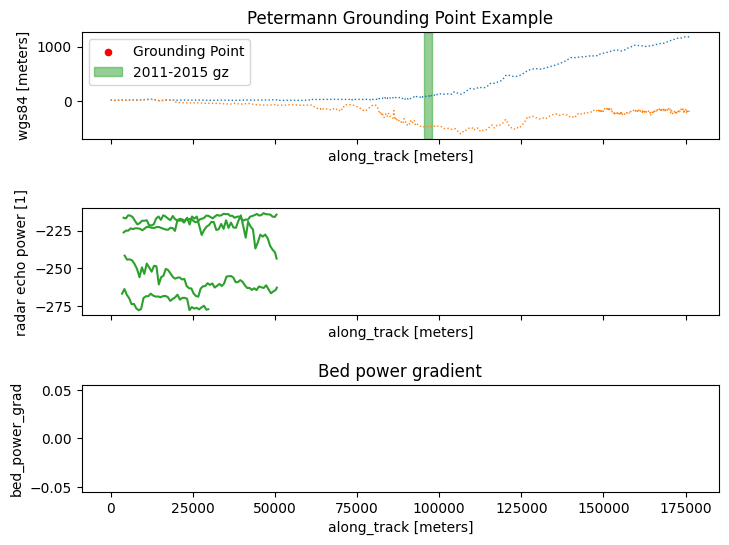

In [93]:
# Plot layers using elevation data and slow_time
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)
fig.tight_layout(pad=4.0)

for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':')#, label=layer_name)

ax1.scatter(reflectivity_merged['along_track'][grad_max_idx], bottom_gp, color='r', s=20, label="Grounding Point")
ax1.set_title('Petermann Grounding Point Example')

ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')

for result in results:
    result = xopr.radar_util.add_along_track(result)
    result['bed_power_dB'].plot(ax=ax2, x='along_track', label='Bed Power dB', color='tab:green')
# ax3.scatter(grad_slowtime, grad_max, color='r', s=20, label="Grounding Point")


# Plot layers using elevation data
#ax3 plot
reflectivity_merged['bed_power_grad'].plot(ax=ax3, x='along_track', label='bed_grad', color='tab:green')
ax3.scatter(reflectivity_merged['along_track'][grad_max_idx], grad_max, color='r', s=20, label="Grounding Point")

ax1.legend()
# ax3.legend()
ax3.set_title('Bed power gradient')
# fig.savefig('/home/m484s199/gline_figures/petermann_20100420_layers.png', dpi=300)

**Issue**: Need to figure out how to make these both along track for the X

In [ ]:
# visualize radargram

clb_min_pct, clb_max_pct = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(frame_1.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=vmin_1, vmax=vmax_1)

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)


ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')

ax1.scatter(reflectivity['along_track'][grad_max_idx], bottom_gp, color='r', s=20, label="Grounding Point")
# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
fig.savefig('/home/m484s199/gline_figures/petermann_20100420_frame.png', dpi=300)

In [ ]:
# Plot layers using elevation data and slow_time
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)
fig.tight_layout(pad=4.0)

for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':')#, label=layer_name)

ax1.scatter(reflectivity_merged['along_track'][grad_max_idx], bottom_gp, color='r', s=20, label="Grounding Point")
ax1.set_title('Petermann Grounding Point Example')

ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')




reflectivity_merged['bed_power_dB'].plot(ax=ax2, x='along_track', label='Bed Power dB', color='tab:green')
# ax3.scatter(grad_slowtime, grad_max, color='r', s=20, label="Grounding Point")


# Plot layers using elevation data
#ax3 plot
reflectivity_merged['bed_power_grad'].plot(ax=ax3, x='along_track', label='bed_grad', color='tab:green')
ax3.scatter(reflectivity_merged['along_track'][grad_max_idx], grad_max, color='r', s=20, label="Grounding Point")

ax1.legend()
# ax3.legend()
ax3.set_title('Bed power gradient')
# fig.savefig('/home/m484s199/gline_figures/petermann_20100420_layers.png', dpi=300)